<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO03/HO03_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HO03 - Text Clustering

In [1]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

### 1. Analisando o dataset

In [2]:
print(f"Type of newsgroups_train: {type(newsgroups_train)}")
print(f"Keys available in the dataset: {newsgroups_train.keys()}")
print(f"Number of samples: {len(newsgroups_train.data)}")
print(f"Number of target categories: {len(newsgroups_train.target_names)}")

Type of newsgroups_train: <class 'sklearn.utils._bunch.Bunch'>
Keys available in the dataset: dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])
Number of samples: 11314
Number of target categories: 20


### 2. Analisando a distribuição das categorias

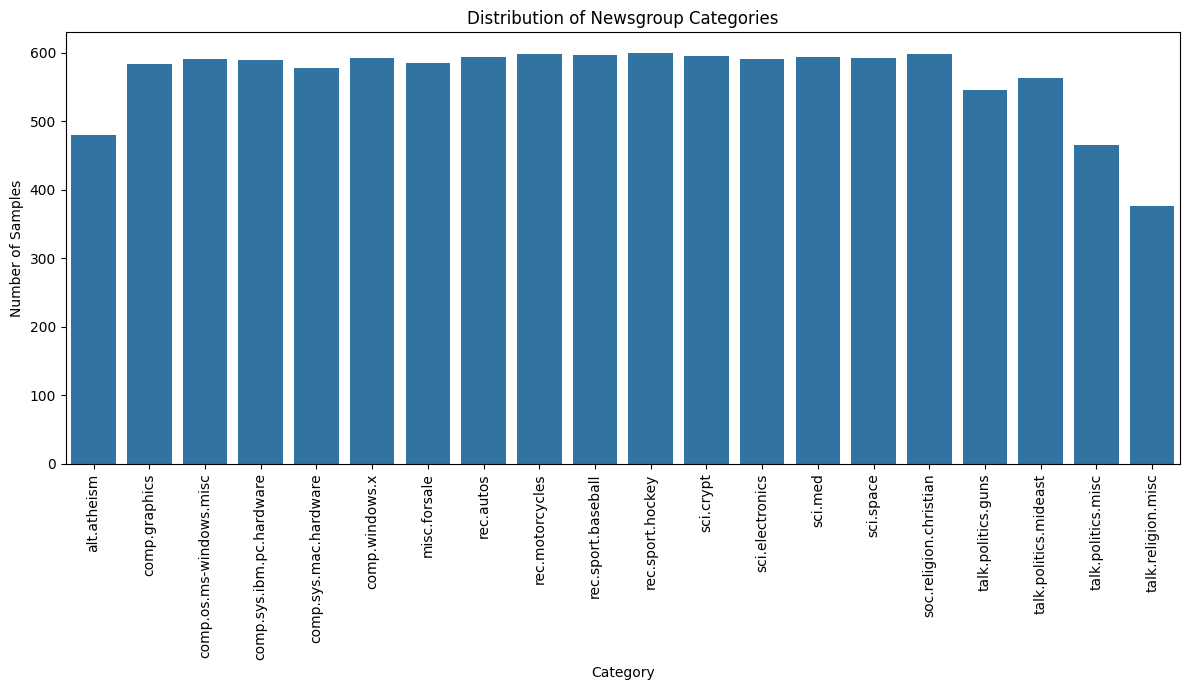

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = pd.Series(newsgroups_train.target).value_counts().sort_index()
target_names = [newsgroups_train.target_names[i] for i in target_counts.index]

plt.figure(figsize=(12, 7))
sns.barplot(x=target_names, y=target_counts.values)
plt.xticks(rotation=90)
plt.title('Distribution of Newsgroup Categories')
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

### 3. Mostrando um documento de exemplo e sua categoria

In [ ]:
import numpy as np

# 1. Acesso por Global Index
sample_index = 11313
print(f"--- [Global] Sample Document ({sample_index}) ---")
print(newsgroups_train.data[sample_index])
print(f"Category: {newsgroups_train.target_names[newsgroups_train.target[sample_index]]}")

print("\n" + "="*50 + "\n")

# 2. Acesso por Categoria e Index relativo
category_id = 1
relative_doc_index = 500

# Encontra os índices globais que pertencem à categoria selecionada
category_indices = np.where(newsgroups_train.target == category_id)[0]

if relative_doc_index < len(category_indices):
    global_idx = category_indices[relative_doc_index]
    print(f"--- [Category {category_id}] Document at relative index {relative_doc_index} ---")
    print(f"Category Name: {newsgroups_train.target_names[category_id]}")
    print(f"Global Index: {global_idx}")
    print("-" * 30)
    print(newsgroups_train.data[global_idx])
else:
    print(f"O índice relativo {relative_doc_index} está fora do range para esta categoria.")

--- [Global] Sample Document (11313) ---
From: gunning@cco.caltech.edu (Kevin J. Gunning)
Subject: stolen CBR900RR
Organization: California Institute of Technology, Pasadena
Lines: 12
Distribution: usa
NNTP-Posting-Host: alumni.caltech.edu
Summary: see above

Stolen from Pasadena between 4:30 and 6:30 pm on 4/15.

Blue and white Honda CBR900RR california plate KG CBR.   Serial number
JH2SC281XPM100187, engine number 2101240.

No turn signals or mirrors, lights taped over for track riders session
at Willow Springs tomorrow.  Guess I'll miss it.  :-(((

Help me find my baby!!!

kjg


Category: rec.motorcycles


--- [Category 1] Document at relative index 500 ---
Category Name: comp.graphics
Global Index: 9827
------------------------------
From: oberto@genes.icgeb.trieste.it (Jacques Oberto)
Subject: Re: HELP!!! GRASP
Organization: ICGEB
Lines: 33

CBW790S@vma.smsu.edu.Ext (Corey Webb) writes:

>In article <1993Apr19.160944.20236W@baron.edb.tih.no>
>havardn@edb.tih.no (Haavard Nesse,o92a

### *4*. Listando o nome de todas as categorias

In [ ]:
print("Target category names:")
for i, name in enumerate(newsgroups_train.target_names):
    print(f"{i}: {name}")

Target category names:
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc


### 6. Função de Normalização de Texto (Remoção de Pontuação)

In [3]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tag import pos_tag

# Baixa os conjuntos de dados necessários se ainda não foram baixados
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# Função auxiliar para mapear as POS tags do NLTK para as tags da WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Padrão para substantivo se não houver tag clara

def normalize_text(text):
    """Remove pontuação, stopwords, realiza POS-tagging e lematiza uma string de texto."""
    # 1. Remover pontuação
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text.translate(translator)

    # 2. Converter para minúsculas e tokenizar
    words = text_no_punct.lower().split()

    # 3. Remover stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # 4. POS-tagging (Parte da Fala)
    pos_tagged_words = pos_tag(filtered_words)

    # 5. Lematização
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = []
    for word, tag in pos_tagged_words:
        wntag = get_wordnet_pos(tag)
        lemmatized_words.append(lemmatizer.lemmatize(word, wntag))

    return ' '.join(lemmatized_words)

# Exemplo de uso da função
sample_text = newsgroups_train.data[0]
print(f"--- Texto original ---\n{sample_text}\n")

normalized_text_full = normalize_text(sample_text)
print(f"--- Texto normalizado (sem pontuação, stopwords, POS-tagging e lematizado) ---\n{normalized_text_full}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


--- Texto original ---
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----






--- Texto normalizado (sem pontuação, stopwords, POS-tagging e lematizado) ---
lerxstwamumdedu wheres thing subject car nntppostinghost rac3wamumdedu organization university maryland college park line 15 wonder anyone could enlighten car saw day 2door sp

### 7. Testando a função de normalização em outros documentos

In [ ]:
# Seleciona alguns índices de documentos diferentes para testar
sample_indices = [1, 500, 1000]

for index in sample_indices:
    print(f"\n--- Documento Original ({index}) ---")
    original_text = newsgroups_train.data[index]
    print(original_text)

    print(f"\n--- Documento Normalizado ({index}) ---")
    normalized_text = normalize_text(original_text)
    print(normalized_text)
    print("="*80)


--- Documento Original (1) ---
From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP-Posting-Host: carson.u.washington.edu

A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next two days, so please add to the network
knowledge base if you have done the clock upgrade and haven't answered this
poll. Thanks.

Guy Kuo <guykuo@u.washington.edu>


--- Documento Normalizado (1) ---
guykuocarsonuwashingtonedu guy kuo subject si clock poll final call summar

### 8. Análise Estatística do Dataset Normalizado

Vamos criar uma função para contar o número de documentos e extrair o vocabulário único resultante da normalização.

In [4]:
def analyze_dataset_stats(dataset):
    """Calcula o número de documentos e a quantidade de palavras únicas após a normalização."""
    num_docs = len(dataset.data)
    unique_words = set()

    print(f"Processando {num_docs} documentos... Por favor, aguarde.")

    for doc in dataset.data:
        # Normaliza o texto
        normalized = normalize_text(doc)
        # Adiciona as palavras ao set de palavras únicas
        unique_words.update(normalized.split())

    return num_docs, len(unique_words)

# Executa a análise
total_docs, vocab_size = analyze_dataset_stats(newsgroups_train)

print(f"\n--- Estatísticas do Dataset ---")
print(f"Quantidade total de documentos: {total_docs}")
print(f"Quantidade de palavras únicas (Vocabulário): {vocab_size}")

Processando 11314 documentos... Por favor, aguarde.

--- Estatísticas do Dataset ---
Quantidade total de documentos: 11314
Quantidade de palavras únicas (Vocabulário): 130805


### 9. Construindo a representação TF-IDF



#### Versão "Manual":
Nesta etapa, vamos transformar o texto normalizado em vetores numéricos seguindo a lógica: Matriz de Contagem (TF) e Matriz IDF.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from scipy.sparse import csr_matrix

# 1. Preparar os dados normalizados (processando novamente para garantir consistência)
print("Normalizando documentos para a matriz...")
corpus_normalized = [normalize_text(doc) for doc in newsgroups_train.data]

# 2. Gerar a Matriz de Contagem (Counting Vectors)
# Limitamos o vocabulário para evitar estouro de memória se necessário,
# mas aqui usaremos o total identificado anteriormente.
vectorizer = CountVectorizer()
counting_matrix = vectorizer.fit_transform(corpus_normalized)

print(f"Formato da Matriz de Contagem: {counting_matrix.shape}")

Normalizando documentos para a matriz...
Formato da Matriz de Contagem: (11314, 130757)


In [ ]:
# 3. Calcular o IDF
# df (document frequency) é o número de documentos que contêm o termo
df = np.diff(counting_matrix.tocsc().indptr)

# Fórmula do IDF: log(N / df) + 1 (usando a suavização padrão do sklearn)
# N é o número total de documentos
N = counting_matrix.shape[0]
idf = np.log((1 + N) / (1 + df)) + 1

print(f"Vetor IDF gerado com {len(idf)} termos.")

Vetor IDF gerado com 130757 termos.


In [ ]:
# 4. Gerar a Matriz TF-IDF
# A multiplicação é elemento a elemento entre a contagem e o peso IDF de cada coluna
from sklearn.preprocessing import normalize

# Criamos uma matriz diagonal de pesos IDF para multiplicar
idf_diag = csr_matrix((idf, (np.arange(len(idf)), np.arange(len(idf)))), shape=(len(idf), len(idf)))
tfidf_matrix_manual = counting_matrix @ idf_diag

# Normalização L2 (comum no TF-IDF para que documentos longos não tenham pesos desproporcionais)
tfidf_matrix_manual = normalize(tfidf_matrix_manual, norm='l2', axis=1)

print("Matriz TF-IDF final gerada com sucesso.")
print(f"Exemplo de valores na primeira linha (primeiros 5 termos não-zero):")
first_row = tfidf_matrix_manual[0].tocoo()
for r, c, v in list(zip(first_row.row, first_row.col, first_row.data))[:5]:
    print(f"  Termo: {vectorizer.get_feature_names_out()[c]} | Peso: {v:.4f}")

Matriz TF-IDF final gerada com sucesso.
Exemplo de valores na primeira linha (primeiros 5 termos não-zero):
  Termo: lerxst | Peso: 0.2152
  Termo: neighborhood | Peso: 0.1554
  Termo: bring | Peso: 0.0965
  Termo: il | Peso: 0.1298
  Termo: thanks | Peso: 0.0675


#### Versão Scikit Learn:

In [10]:
corpus_normalized = [normalize_text(doc) for doc in newsgroups_train.data]

from sklearn.feature_extraction.text import TfidfVectorizer

# Gerar a Matriz TF-IDF usando TfidfVectorizer
print("Gerando a Matriz TF-IDF usando TfidfVectorizer...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix_sklearn = tfidf_vectorizer.fit_transform(corpus_normalized)

print(f"Formato da Matriz TF-IDF (Sklearn): {tfidf_matrix_sklearn.shape}")
print(f"Exemplo de feature names: {tfidf_vectorizer.get_feature_names_out()[:5]}")

print("\nExemplo dos 10 primeiros termos não-zero da primeira linha (Sklearn):")
first_row_sklearn = tfidf_matrix_sklearn[0].tocoo()
feature_names_sklearn = tfidf_vectorizer.get_feature_names_out()

non_zero_terms_count = 0
for r, c, v in zip(first_row_sklearn.row, first_row_sklearn.col, first_row_sklearn.data):
    if v != 0 and non_zero_terms_count < 10:
        print(f"  Termo: {feature_names_sklearn[c]} | Peso: {v:.4f}")
        non_zero_terms_count += 1
    if non_zero_terms_count >= 10:
        break

Gerando a Matriz TF-IDF usando TfidfVectorizer...
Formato da Matriz TF-IDF (Sklearn): (11314, 130757)
Exemplo de feature names: ['00' '000' '0000' '00000' '000000']

Exemplo dos 10 primeiros termos não-zero da primeira linha (Sklearn):
  Termo: lerxstwamumdedu | Peso: 0.2152
  Termo: wheres | Peso: 0.1698
  Termo: thing | Peso: 0.0628
  Termo: subject | Peso: 0.0233
  Termo: car | Peso: 0.4444
  Termo: nntppostinghost | Peso: 0.0434
  Termo: rac3wamumdedu | Peso: 0.1954
  Termo: organization | Peso: 0.0242
  Termo: university | Peso: 0.0450
  Termo: maryland | Peso: 0.1337


### NOTA:
Muito provavelmente o termo **lerxst** é referente ao destinatário ou rementente do email. O fato dele ter um peso um pouco mais alto do que palavras como "**thanks**" ou "**bring**" indica que a normalização TF-IDF funcionou certinho. Mas talvez essa palavra devesse ser tratada como um ruido

### 10. Representação Word2Vec

Enquanto o TF-IDF foca na importância estatística das palavras, o Word2Vec cria embeddings densos que capturam relações semânticas entre elas. Vamos usar a biblioteca `gensim` para esta tarefa.

In [12]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.2 MB/s eta 0:00:00


In [13]:
from gensim.models import Word2Vec
import logging

# 1. Preparar os dados (Word2Vec espera uma lista de listas de tokens)
print("Preparando tokens para o Word2Vec...")
tokenized_corpus = [doc.split() for doc in corpus_normalized]

# 2. Treinar o modelo Word2Vec
print("Treinando o modelo Word2Vec (isso pode levar alguns instantes)...")
w2v_model = Word2Vec(sentences=tokenized_corpus,
                     vector_size=100,
                     window=5,
                     min_count=2,
                     workers=4)

print("Modelo Word2Vec treinado com sucesso!")

Preparando tokens para o Word2Vec...
Treinando o modelo Word2Vec (isso pode levar alguns instantes)...
Modelo Word2Vec treinado com sucesso!


In [14]:
# 3. Demonstrando o Word2Vec: Encontrando palavras similares
word_to_test = "image"
if word_to_test in w2v_model.wv:
    print(f"Palavras mais similares a '{word_to_test}':")
    similar_words = w2v_model.wv.most_similar(word_to_test, topn=5)
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")

# Exemplo de vetor para uma palavra
print(f"\nFormato do vetor da palavra '{word_to_test}': {w2v_model.wv[word_to_test].shape}")

Palavras mais similares a 'image':
  map: 0.8944
  jpeg: 0.8742
  render: 0.8705
  display: 0.8559
  gif: 0.8531

Formato do vetor da palavra 'image': (100,)


In [34]:
# Contar o número de vetores zero em w2v_vectors
num_zero_vectors = np.sum(np.all(w2v_vectors == 0, axis=1))
print(f"Número de vetores Word2Vec zero: {num_zero_vectors} de {len(w2v_vectors)}")

if num_zero_vectors > 0:
    print("Isso indica que alguns documentos não contêm palavras que aparecem no modelo Word2Vec, resultando em vetores zero.")
    print("Se este número for muito alto, pode impactar a qualidade da clusterização baseada em Word2Vec.")
else:
    print("Não há vetores Word2Vec zero, o problema pode estar em outro lugar ou nos centróides resultantes do agrupamento.")

Número de vetores Word2Vec zero: 0 de 11314
Não há vetores Word2Vec zero, o problema pode estar em outro lugar ou nos centróides resultantes do agrupamento.


### 11. Função para Plotar pontos em um mapa

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
import sklearn.mixture as GMM
import time
import hdbscan
%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}

Usando 'tfidf_matrix_sklearn' para representação TF-IDF.
Variável 'data_tfidf' criada com sucesso.
Variável 'data_word2vec' criada com sucesso.


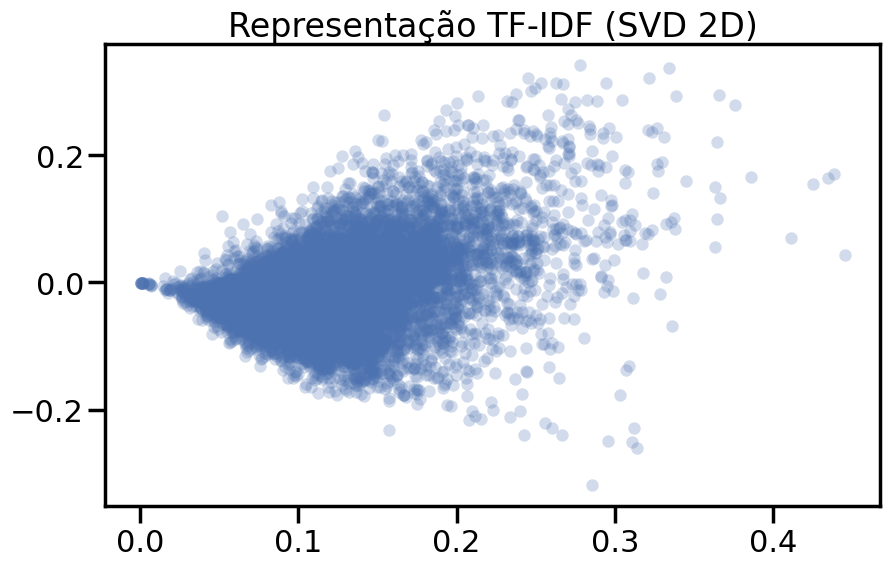

In [17]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

# 1. Criando representação 2D para TF-IDF
tfidf_data_source = None
if 'tfidf_matrix_sklearn' in globals():
    tfidf_data_source = tfidf_matrix_sklearn
    print("Usando 'tfidf_matrix_sklearn' para representação TF-IDF.")
elif 'tfidf_matrix_manual' in globals():
    tfidf_data_source = tfidf_matrix_manual
    print("Usando 'tfidf_matrix_manual' para representação TF-IDF.")
else:
    print("Aviso: Nenhuma matriz TF-IDF (sklearn ou manual) encontrada. Execute as células anteriores.")

if tfidf_data_source is not None:
    svd = TruncatedSVD(n_components=2, random_state=42)
    data_tfidf = svd.fit_transform(tfidf_data_source)
    print("Variável 'data_tfidf' criada com sucesso.")
else:
    data_tfidf = None # Garante que data_tfidf não existe se nenhuma fonte foi encontrada

# 2. Criando representação 2D para Word2Vec
if 'w2v_model' in globals() and 'tokenized_corpus' in globals():
    # Calculando o vetor médio para cada documento
    def get_mean_vector(model, words):
        words = [w for w in words if w in model.wv]
        if len(words) >= 1:
            return np.mean(model.wv[words], axis=0)
        return np.zeros((model.vector_size,))

    w2v_vectors = np.array([get_mean_vector(w2v_model, doc) for doc in tokenized_corpus])

    # Reduzindo para 2D
    svd_w2v = TruncatedSVD(n_components=2, random_state=42)
    data_word2vec = svd_w2v.fit_transform(w2v_vectors)
    print("Variável 'data_word2vec' criada com sucesso.")
else:
    print("Aviso: Modelo Word2Vec não encontrado.")
    data_word2vec = None # Garante que data_word2vec não existe se o modelo não foi encontrado

# Plot de exemplo (TF-IDF)
if data_tfidf is not None:
    plt.figure(figsize=(10, 6))
    plt.scatter(data_tfidf.T[0], data_tfidf.T[1], c='b', **plot_kwds)
    plt.title('Representação TF-IDF (SVD 2D)')
    plt.show()

In [40]:
def plot_clusters(data, algorithm, args, kwds, show_details=False, vector_type='tfidf',
                  full_tfidf_matrix=None, tfidf_extractor=None):
    """
    Executa o algoritmo, plota os resultados e opcionalmente exibe detalhes dos clusters.
    vector_type: 'tfidf' ou 'word2vec'
    full_tfidf_matrix: A matriz TF-IDF completa (não a versão 2D reduzida).
    tfidf_extractor: O objeto (TfidfVectorizer ou CountVectorizer) usado para extrair features.
    """
    start_time = time.time()
    algo_instance = algorithm(*args, **kwds)
    labels = algo_instance.fit_predict(data)
    end_time = time.time()

    # Plotagem
    palette = sns.color_palette('deep', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters by {}'.format(str(algorithm.__name__)), fontsize=18)
    plt.text(-0.5, 0.6, 'Running Time {:.2f} s'.format(end_time - start_time), fontsize=14)
    plt.show()

    # Injeção da análise de detalhes
    if show_details:
        if vector_type == 'tfidf':
            if full_tfidf_matrix is None or tfidf_extractor is None:
                print("Erro: full_tfidf_matrix e tfidf_extractor devem ser fornecidos para 'tfidf' vector_type quando show_details=True.")
            else:
                show_cluster_details(data, labels, tfidf_extractor, newsgroups_train.data, full_tfidf_matrix)
        elif vector_type == 'word2vec':
            show_w2v_cluster_details(w2v_vectors, labels, w2v_model, newsgroups_train.data)

In [39]:
def show_cluster_details(data_vectors_2d, labels, tfidf_extractor, original_docs, full_tfidf_matrix, n_top_words=20, n_top_docs=10):
    """
    Exibe os principais termos e documentos representativos para cada cluster.
    """
    labels = np.array(labels)
    unique_labels = np.unique(labels)
    # Filtrar ruído se necessário (ex: -1 no HDBSCAN/DBSCAN)
    unique_labels = [l for l in unique_labels if l != -1]

    feature_names = tfidf_extractor.get_feature_names_out()

    for i in unique_labels:
        print(f"\n{'='*30}")
        print(f"  CLUSTER {i}")
        print(f"{'='*30}")

        # 1. Encontrar top tokens (média dos pesos TF-IDF no cluster)
        cluster_indices = np.where(labels == i)[0]
        # Use the full TF-IDF matrix here, not the 2D projected one
        cluster_tfidf = full_tfidf_matrix[cluster_indices]
        mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).flatten()
        top_word_indices = mean_tfidf.argsort()[::-1][:n_top_words]

        print(f"\nTop-{n_top_words} Tokens:")
        print(", ".join([feature_names[idx] for idx in top_word_indices]))

        # 2. Encontrar top documentos (amostragem ou proximidade)
        # Para simplificar, mostraremos os primeiros N documentos atribuídos ao cluster
        print(f"\nTop-{n_top_docs} Documentos (Amostras):")
        for doc_idx in cluster_indices[:n_top_docs]:
            # Mostra apenas os primeiros 150 caracteres para não poluir o output
            doc_snippet = original_docs[doc_idx].replace('\n', ' ')[:150]
            print(f" - [Doc {doc_idx}]: {doc_snippet}...")

In [35]:
def show_w2v_cluster_details(full_doc_w2v_vectors, labels, model, original_docs, n_top_words=10, n_top_docs=10):
    """
    Exibe detalhes dos clusters usando similaridade semântica do Word2Vec.
    `full_doc_w2v_vectors` deve ser a matriz de vetores Word2Vec 100D para cada documento.
    """
    labels = np.array(labels)
    unique_labels = [l for l in np.unique(labels) if l != -1]

    for i in unique_labels:
        print(f"\n{'='*30}\n  CLUSTER {i} (Word2Vec)\n{'='*30}")

        # 1. Top Tokens por similaridade de vetor (Semântica)
        cluster_indices = np.where(labels == i)[0]
        # Calculate centroid from the original 100D W2V vectors
        centroid = full_doc_w2v_vectors[cluster_indices].mean(axis=0)

        print(f"\nPalavras semanticamente próximas ao centro do cluster:")
        try:
            # Ensure the centroid is not all zeros by checking its norm
            if np.linalg.norm(centroid) > 1e-6:  # Using a small threshold for 'effectively zero'
                closest_words = model.wv.most_similar(positive=[centroid], topn=n_top_words)
                print(", ".join([word for word, score in closest_words]))
            else:
                print("Centróide do cluster é um vetor zero (ou muito próximo de zero). Não foi possível extrair palavras similares.")
        except Exception as e:
            print(f"Não foi possível extrair palavras similares. Erro: {e}")

        # 2. Amostra de Documentos
        print(f"\nTop-{n_top_docs} Documentos (Amostras):")
        for doc_idx in cluster_indices[:n_top_docs]:
            doc_snippet = original_docs[doc_idx].replace('\n', ' ')[:150]
            print(f" - [Doc {doc_idx}]: {doc_snippet}...")

#### Explicação das Funções de Detalhe dos Clusters

Duas funções auxiliares foram criadas para ajudar na interpretação dos clusters:

*   **`show_cluster_details(data_vectors, labels, vectorizer, original_docs, ...)`**:
    *   Utilizada para clusters baseados em representações como **TF-IDF**.
    *   Identifica as `n_top_words` mais representativas de cada cluster, calculando a média dos pesos TF-IDF dos termos nos documentos do cluster.
    *   Exibe amostras dos `n_top_docs` documentos pertencentes a cada cluster.
    *   Ajuda a entender os tópicos dominantes de um cluster através da importância estatística das palavras.

*   **`show_w2v_cluster_details(data_vectors, labels, model, original_docs, ...)`**:
    *   Utilizada para clusters baseados em representações como **Word2Vec**.
    *   Tenta encontrar palavras semanticamente mais próximas ao centróide de cada cluster no espaço de embeddings do Word2Vec.
    *   Exibe amostras dos `n_top_docs` documentos pertencentes a cada cluster.
    *   Ajuda a entender a coerência semântica de um cluster através da similaridade de significado das palavras.

### 12. Clusterização com K-Means (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


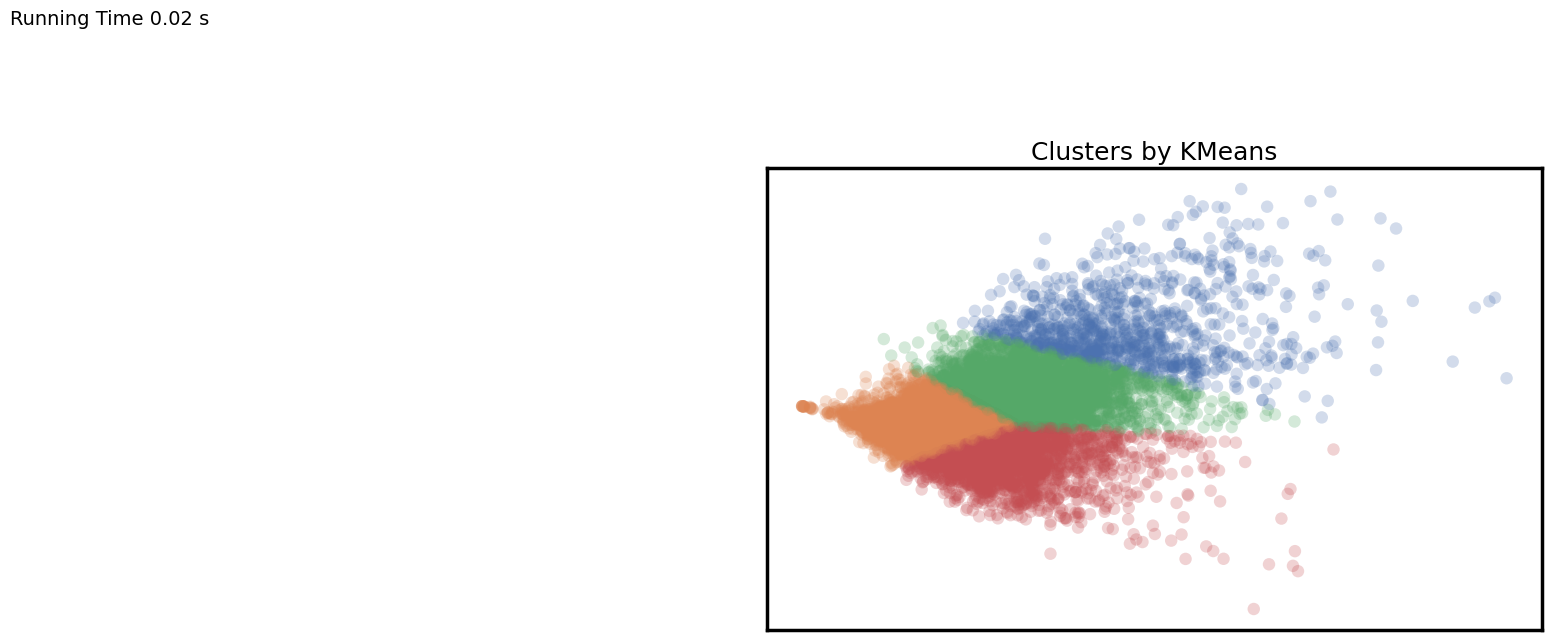


  CLUSTER 0

Top-20 Tokens:
god, people, say, christian, one, jesus, would, think, believe, dont, make, know, right, bible, go, thing, see, life, write, come

Top-10 Documentos (Amostras):
 - [Doc 11]: From: david@terminus.ericsson.se (David Bold) Subject: Re: Question for those with popular morality Reply-To: david@terminus.ericsson.se Distribution:...
 - [Doc 28]: From: jonh@david.wheaton.edu (Jonathan Hayward) Subject: Re: Pantheism & Environmentalism Organization: Wheaton College, IL Lines: 46  In article <Apr...
 - [Doc 37]: From: ebrandt@jarthur.claremont.edu (Eli Brandt) Subject: Re: Do we need the clipper for cheap security? Organization: Harvey Mudd College, Claremont,...
 - [Doc 51]: From: dlecoint@garnet.acns.fsu.edu (Darius_Lecointe) Subject: Re: Sabbath Admissions 5of5 Organization: Florida State University Lines: 27  I have bee...
 - [Doc 68]: From: chrisb@seachg.com (Chris Blask) Subject: Re: islamic authority over women Reply-To: chrisb@seachg.com (Chris Blask) Organiz

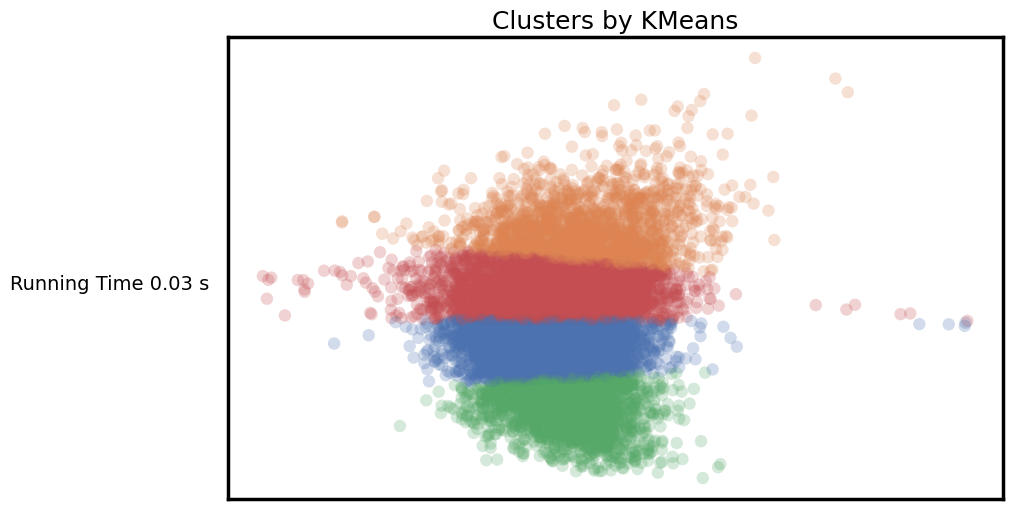


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
bizarre, friends, odds, meantime, garbage, shortage, prepared, incidentally, c5l40c9lcmurdochaccvirginiaedu, plenty

Top-10 Documentos (Amostras):
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical Observatory, Cambridge...
 - [Doc 13]: From: dbm0000@tm0006.lerc.nasa.gov (David B. Mckissock) Subject: Re: Space Station Redesign, JSC Alternative #4 Organization: NASA Lewis Research Cent...
 - [Doc 16]: From: ab@nova.cc.purdue.edu (Allen B) Subject: Re: TIFF: philosophical significance of 42 Organization: Purdue University Lines: 39  In article <prest...
 - [Doc 17]: From: CPKJP@vm.cc.latech.edu (Kevin Parker) Subject: Insurance Rates on Performance Cars SUMMA

In [42]:
n_clusters = 4

print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.KMeans, (), {'n_clusters': n_clusters},
              show_details=True, vector_type='tfidf',
              full_tfidf_matrix=tfidf_matrix_sklearn, tfidf_extractor=tfidf_vectorizer)

print("\n" + "="*50 + "\n")

print("Clusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.KMeans, (), {'n_clusters': n_clusters},
              show_details=True, vector_type='word2vec')

### 13. Clusterização com Spectral Clustering (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


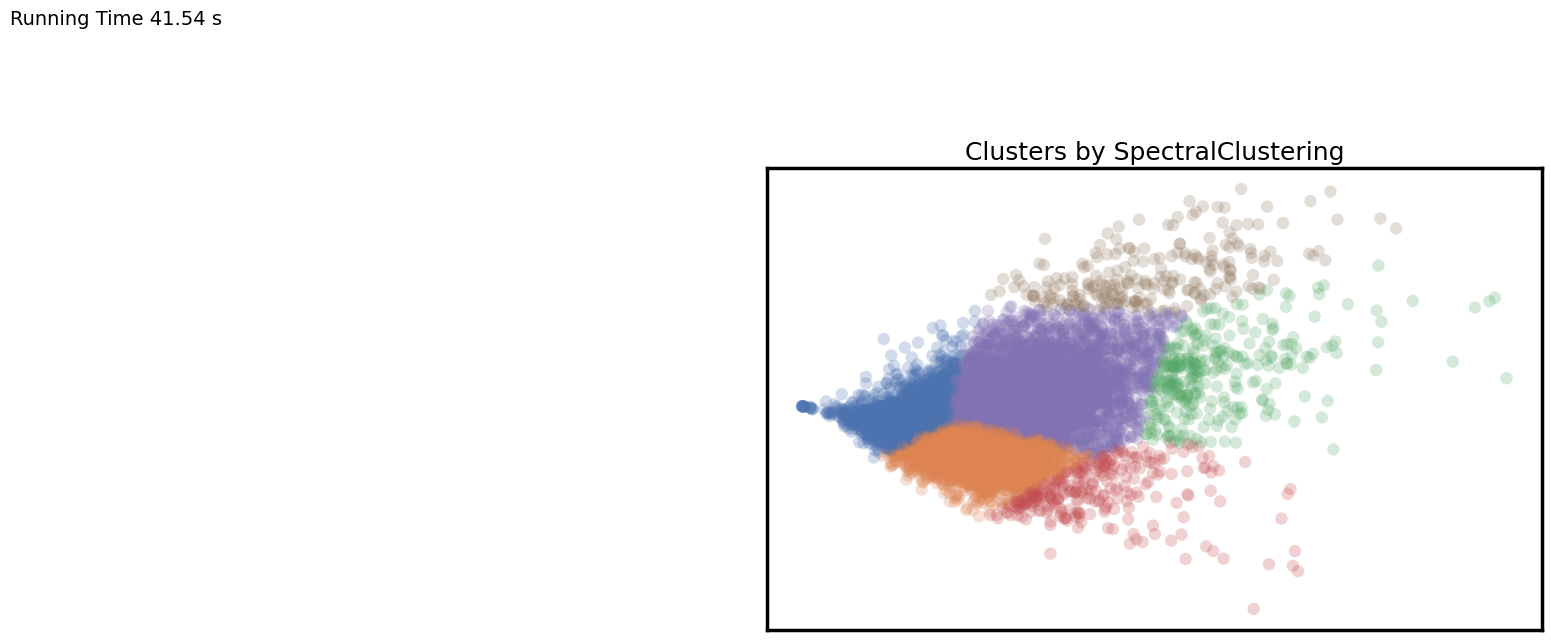


  CLUSTER 0

Top-20 Tokens:
line, subject, organization, university, nntppostinghost, write, article, distribution, replyto, thanks, sale, new, 11, know, anyone, one, 10, usa, email, would

Top-10 Documentos (Amostras):
 - [Doc 12]: From: rodc@fc.hp.com (Rod Cerkoney) Subject: *$G4qxF,fekVH6 Nntp-Posting-Host: hpfcmrc.fc.hp.com Organization: Hewlett Packard, Fort Collins, CO X-New...
 - [Doc 21]: From: leunggm@odin.control.utoronto.ca (Gary Leung) Subject: Re: NHL Team Captains Organization: University of Toronto, Systems Control Group Lines: 2...
 - [Doc 27]: From: r4938585@joplin.biosci.arizona.edu (Doug Roberts) Subject: Re: NL vs. AL? Organization: University of Arizona, Biotechnology, Tucson Lines: 2 NN...
 - [Doc 31]: Subject: Teenage acne From: pchurch@swell.actrix.gen.nz (Pat Churchill) Organization: Actrix Networks Lines: 26   My 14-y-o son has the usual teenage ...
 - [Doc 32]: From: xandor@unixg.ubc.ca (John Gilbert ) Subject: Re: Exploding TV! Organization: The University 

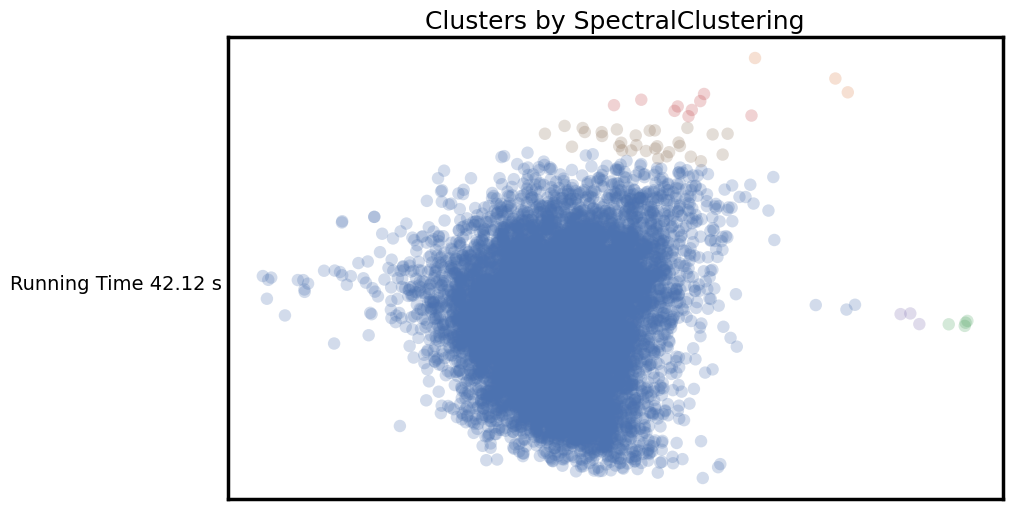


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
bizarre, shortage, garbage, meantime, cancel, excite, mucho, outrageous, bingo, odds

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 3]: From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-H...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical 

In [43]:
# Para clusterizar usando TF-IDF:
n_clusters = 6
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.SpectralClustering, (), {'n_clusters': n_clusters},
              show_details=True, vector_type='tfidf',
              full_tfidf_matrix=tfidf_matrix_sklearn, tfidf_extractor=tfidf_vectorizer)
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.SpectralClustering, (), {'n_clusters': n_clusters},
              show_details=True, vector_type='word2vec')

### 14. Clusterização com Gaussian Mixture (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


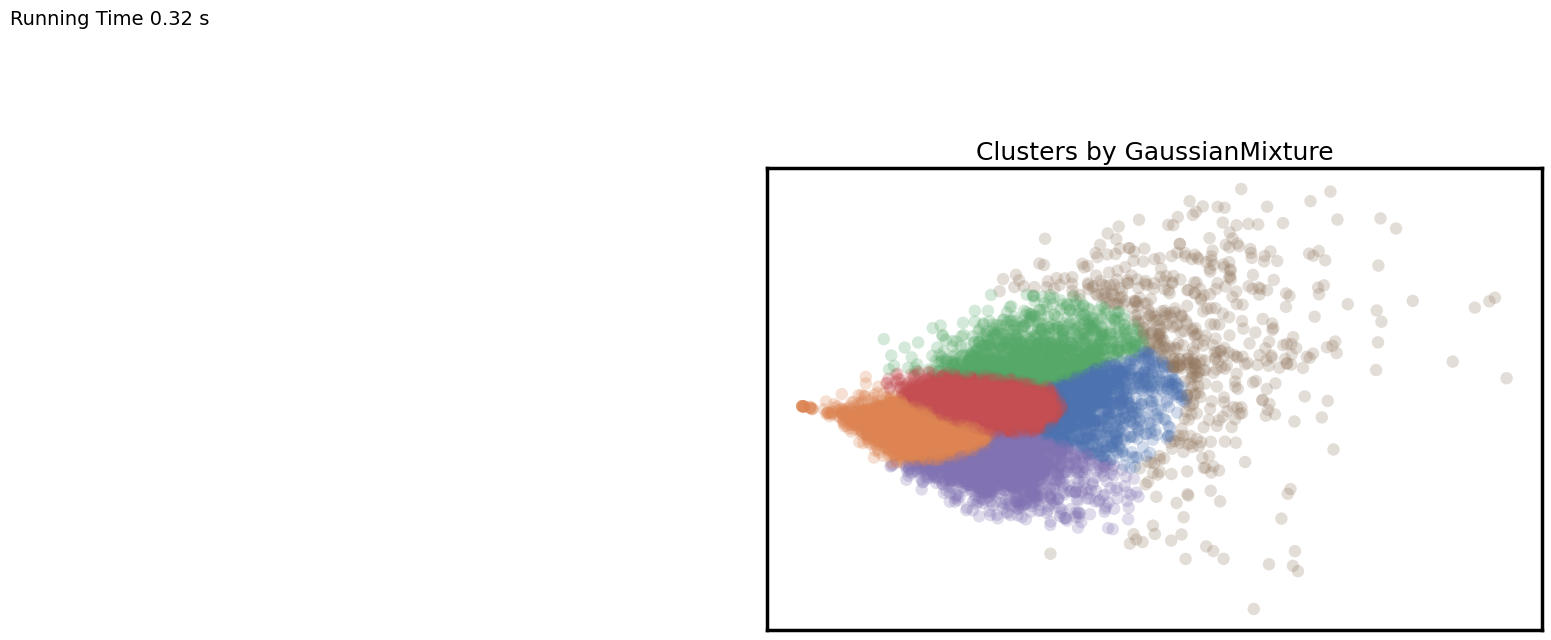

Erro: full_tfidf_matrix e tfidf_extractor devem ser fornecidos para 'tfidf' vector_type quando show_details=True.

Clusterização usando Word2Vec:


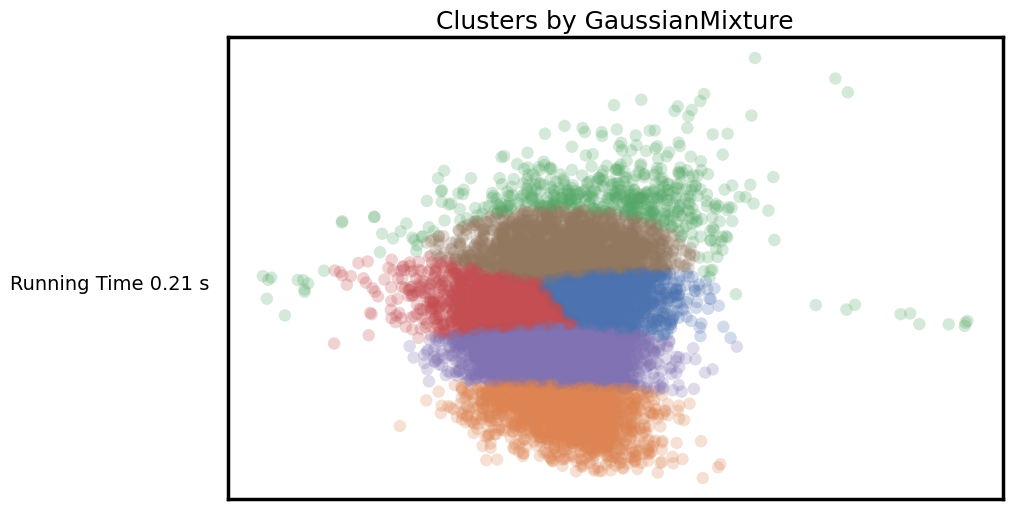


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
built, garbage, handy, import, recommendation, bizarre, hivoltage, adaptecs, heres, mym

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical Observatory, Cambridge...
 - [Doc 6]: From: bmdelane@quads.uchicago.edu (brian manning delaney) Subject: Brain Tumor Treatment (thanks) Reply-To: bmdelane@midway.u

In [44]:
# Para clusterizar usando TF-IDF:
n_clusters = 6
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, GMM.GaussianMixture, (), {'n_components': n_clusters},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, GMM.GaussianMixture, (), {'n_components': n_clusters},show_details=True, vector_type='word2vec')
plt.show()

### 15. Clusterização com Agglomerative Clustering (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


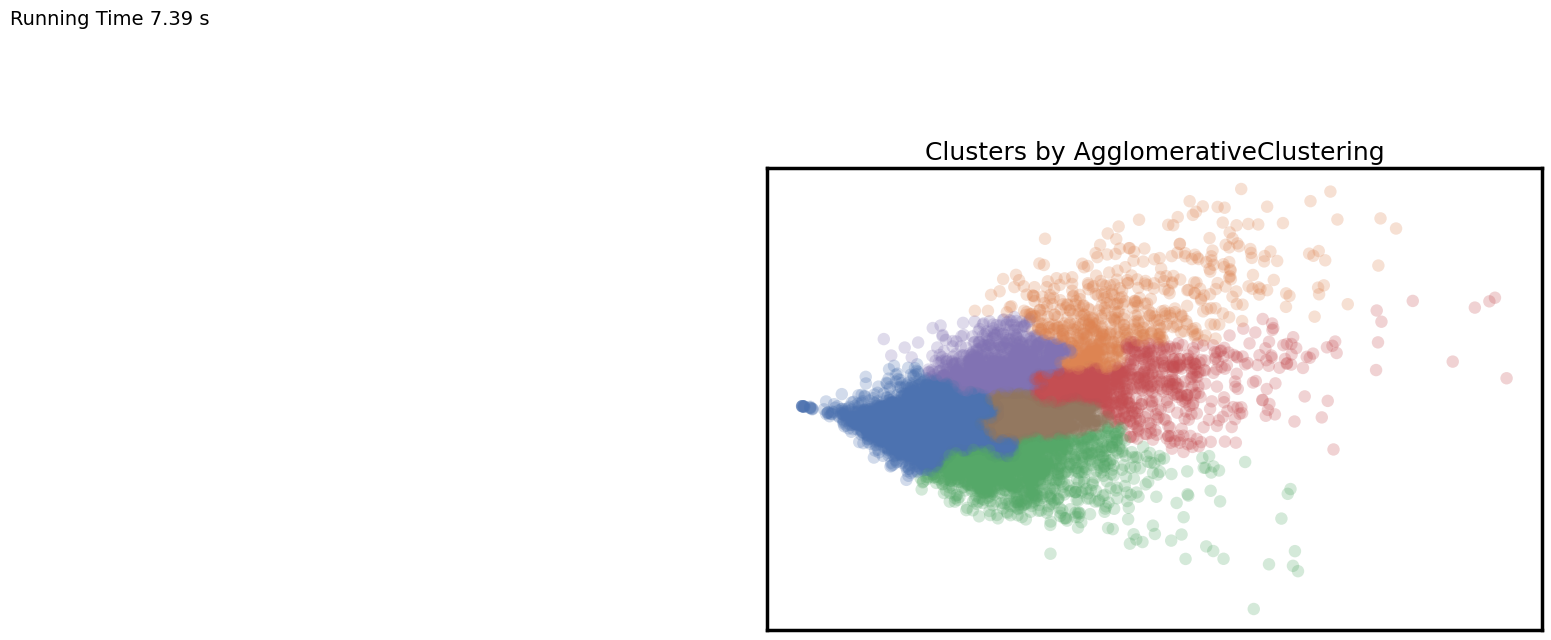

Erro: full_tfidf_matrix e tfidf_extractor devem ser fornecidos para 'tfidf' vector_type quando show_details=True.

Clusterização usando Word2Vec:


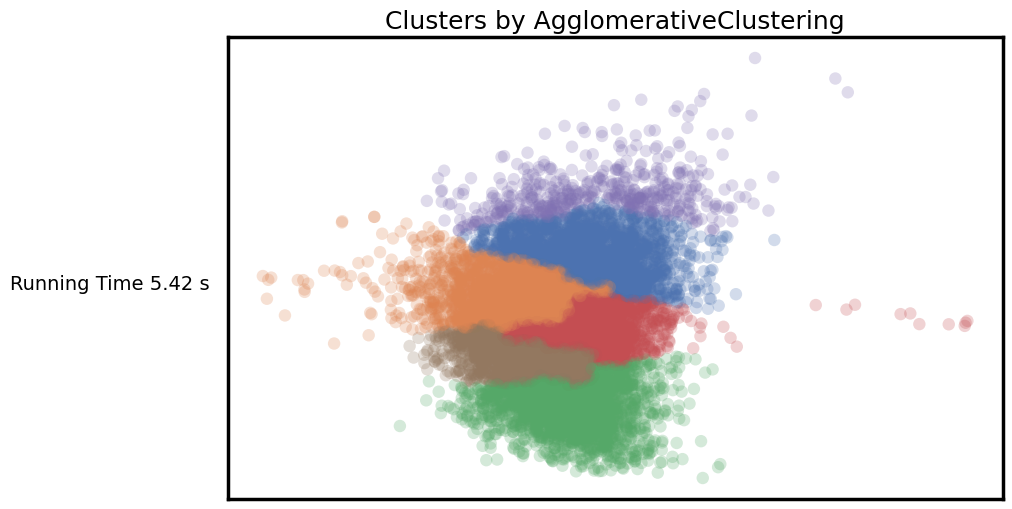


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
doswindows, pricing, miscellaneous, 400dpi, mag, vlbisaeisa, mainframe, connects, docs, doubledisk

Top-10 Documentos (Amostras):
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 3]: From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-H...
 - [Doc 7]: From: bgrubb@dante.nmsu.edu (GRUBB) Subject: Re: IDE vs SCSI Organization: New Mexico State University, Las Cruces, NM Lines: 44 Distribution: world N...
 - [Doc 8]: From: holmes7000@iscsvax.uni.edu Subject: WIn 3.0 ICON HELP PLEASE! Organization: University of Northern Iowa Lines: 10  I have win 3.0 and downloaded...
 - [Doc 19]: From: abarden@tybse1.uucp (Ann Marie Barden) Subject: X-Terminal Config. file question Organization: Tybrin Corpo

In [45]:
# Para clusterizar usando TF-IDF:
n_clusters = 6
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.AgglomerativeClustering, (), {'n_clusters':n_clusters, 'linkage':'ward'},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.AgglomerativeClustering, (), {'n_clusters':n_clusters, 'linkage':'ward'},show_details=True, vector_type='word2vec')
plt.show()

### 16. Clusterização com DBSCAN (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


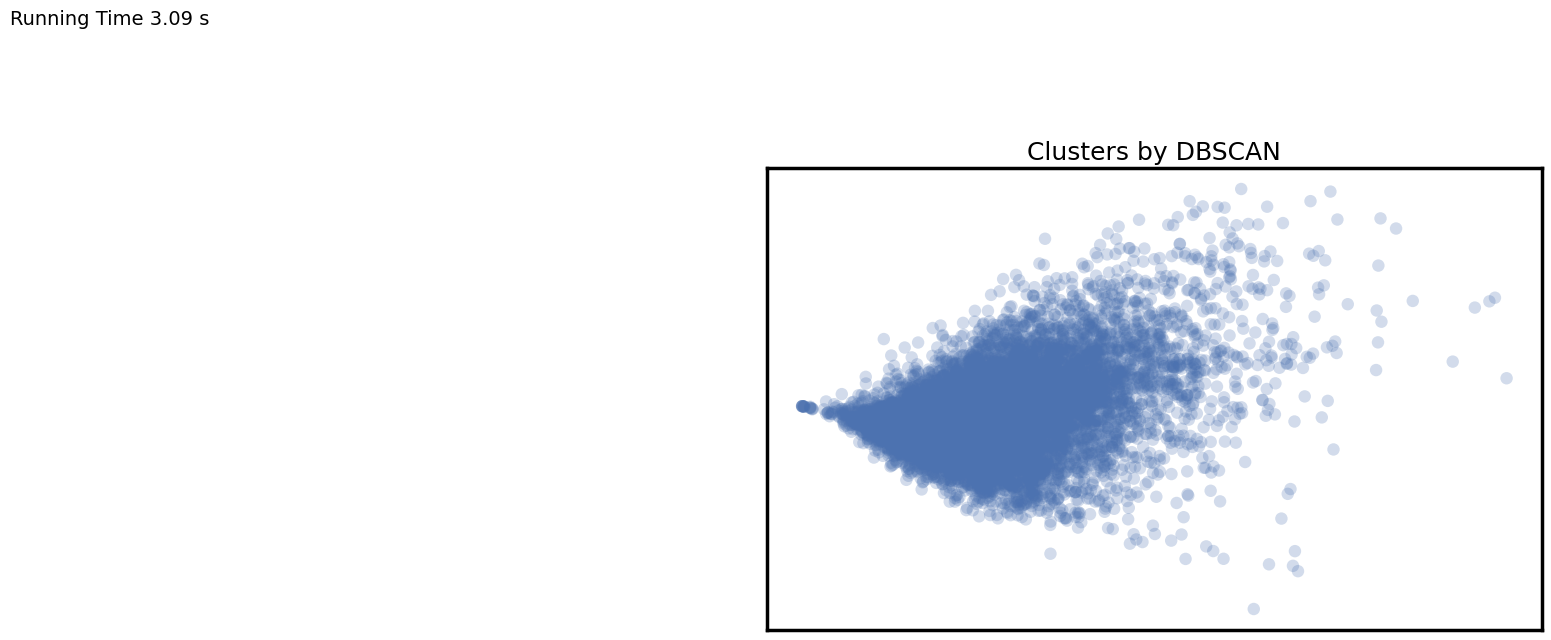

Erro: full_tfidf_matrix e tfidf_extractor devem ser fornecidos para 'tfidf' vector_type quando show_details=True.

Clusterização usando Word2Vec:


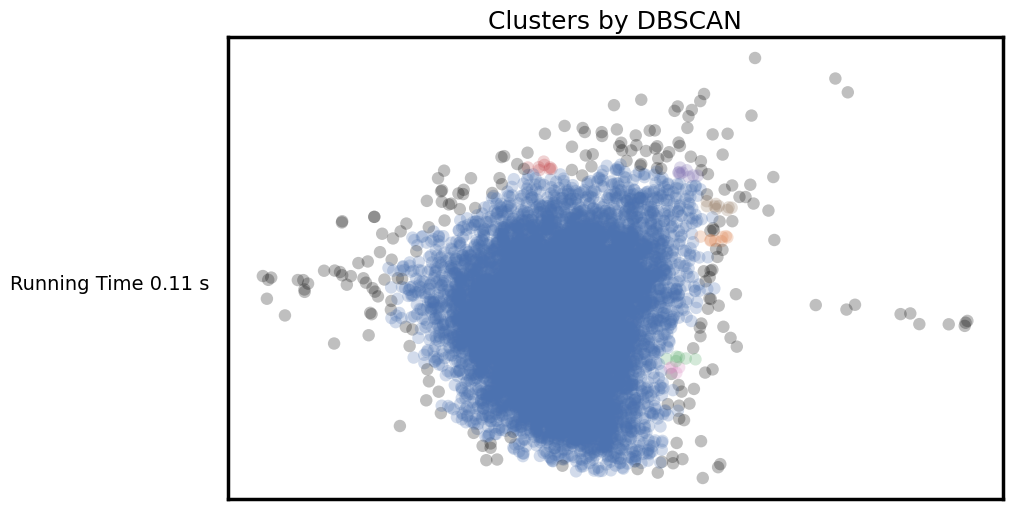


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
bizarre, shortage, garbage, meantime, cancel, excite, mucho, outrageous, odds, bingo

Top-10 Documentos (Amostras):
 - [Doc 0]: From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, Coll...
 - [Doc 1]: From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,...
 - [Doc 2]: From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: ...
 - [Doc 3]: From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-H...
 - [Doc 4]: From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical 

In [46]:
# Para clusterizar usando TF-IDF:
#eps=0.025
eps=0.1
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, cluster.DBSCAN, (), {'eps':eps},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, cluster.DBSCAN, (), {'eps':eps},show_details=True, vector_type='word2vec')
plt.show()

### 17. Clusterização com HDBSCAN (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

Clusterização usando TF-IDF:


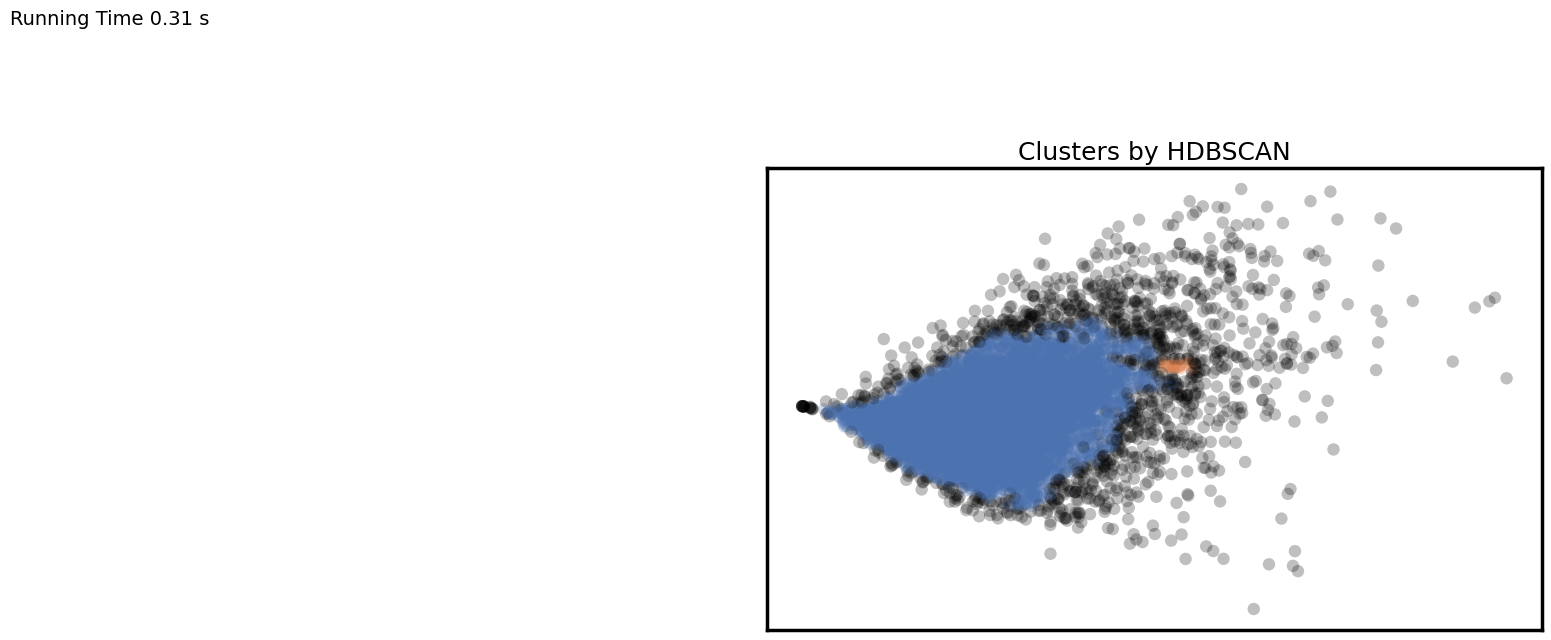

Erro: full_tfidf_matrix e tfidf_extractor devem ser fornecidos para 'tfidf' vector_type quando show_details=True.

Clusterização usando Word2Vec:


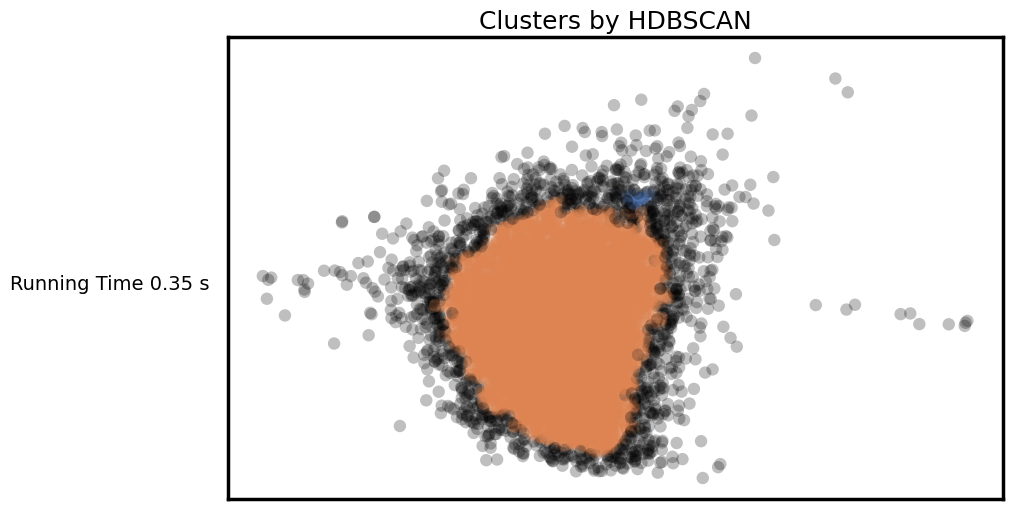


  CLUSTER 0 (Word2Vec)

Palavras semanticamente próximas ao centro do cluster:
pricing, aps, zeos, mainframe, doswindows, p9000, misc, telepath, xgobi, inquire

Top-10 Documentos (Amostras):
 - [Doc 41]: From: root@ncube.com (Operator) Subject: Re: Which fax modem is the best? Nntp-Posting-Host: admin Reply-To: root@ncube.com Organization: nCUBE Corp.,...
 - [Doc 132]: From: steveg@bach.udel.edu (Steven N Gaudino) Subject: Dbase IV for sale (price reduced!) Nntp-Posting-Host: bach.udel.edu Organization: University of...
 - [Doc 515]: From: wongda@eecg.toronto.edu (Daniel Y.H. Wong) Subject: LOOKING FOR THE LATEST ACTIX DRIVERS FOR WINDOWS Organization: Dept. of Electrical Engineeri...
 - [Doc 538]: From: jed@pollux.usc.edu (Jonathan DeMarrais) Subject: Crypto Conference Organization: University of Southern California, Los Angeles, CA Lines: 11 Di...
 - [Doc 882]: From: unpingco@raman.ucsd.edu (Jose Unpingco) Subject: FOR SALE: ULTRABOTS PC GAME Keywords: ULTRABOTS,video game, pc game 

In [47]:
# Para clusterizar usando TF-IDF:
#min_clusters=15
min_clusters=20
print("Clusterização usando TF-IDF:")
plt.figure(figsize=(10, 6))
plot_clusters(data_tfidf, hdbscan.HDBSCAN, (), {'min_cluster_size':min_clusters},show_details=True, vector_type='tfidf')
plt.show()

# Para clusterizar usando Word2Vec:
print("\nClusterização usando Word2Vec:")
plt.figure(figsize=(10, 6))
plot_clusters(data_word2vec, hdbscan.HDBSCAN, (), {'min_cluster_size':min_clusters},show_details=True, vector_type='word2vec')
plt.show()

### 18. Clusterização com Hierarchical Clustering (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.

In [48]:
from scipy.cluster.hierarchy import ward, dendrogram
from sklearn.metrics.pairwise import cosine_similarity

In [49]:
def ward_hierarchical_clustering(feature_matrix):

    cosine_distance = 1 - cosine_similarity(feature_matrix)
    linkage_matrix = ward(cosine_distance)
    return linkage_matrix

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_hierarchical_clusters(linkage_matrix, dataframe, p=100, figure_size=(8,12)):
    # set size
    fig, ax = plt.subplots(figsize=figure_size)
    # Now, access 'title' from the generic 'dataframe' parameter.
    df_titles = dataframe['title'].values.tolist()
    # plot dendrogram
    R = dendrogram(linkage_matrix, orientation="left", labels=df_titles,
                    truncate_mode='lastp',
                    p=p,
                    no_plot=True)
    temp = {R["leaves"][ii]: df_titles[ii] for ii in range(len(R["leaves"]))}
    def llf(xx):
        return "{}".format(temp[xx])
    ax = dendrogram(
            linkage_matrix,
            truncate_mode='lastp',
            orientation="left",
            p=p,
            leaf_label_func=llf,
            leaf_font_size=10.,
            )
    plt.tick_params(axis= 'x',
                    which='both',
                    bottom='off',
                    top='off',
                    labelbottom='off')
    plt.tight_layout()
    plt.savefig('movie_hierachical_clusters.png', dpi=200)

In [51]:
linkage_matrix_tfidf = ward_hierarchical_clustering(data_tfidf)
linkage_matrix_word2vec = ward_hierarchical_clustering(data_word2vec)

In [52]:
np.set_printoptions(suppress=True)
print(linkage_matrix_tfidf)

[[   14.          5392.             0.             2.        ]
 [ 2002.         10777.             0.             2.        ]
 [ 2217.          2726.             0.             2.        ]
 ...
 [22619.         22622.           923.30642076  5513.        ]
 [22620.         22623.          1227.25110635  5801.        ]
 [22624.         22625.          2029.78062212 11314.        ]]


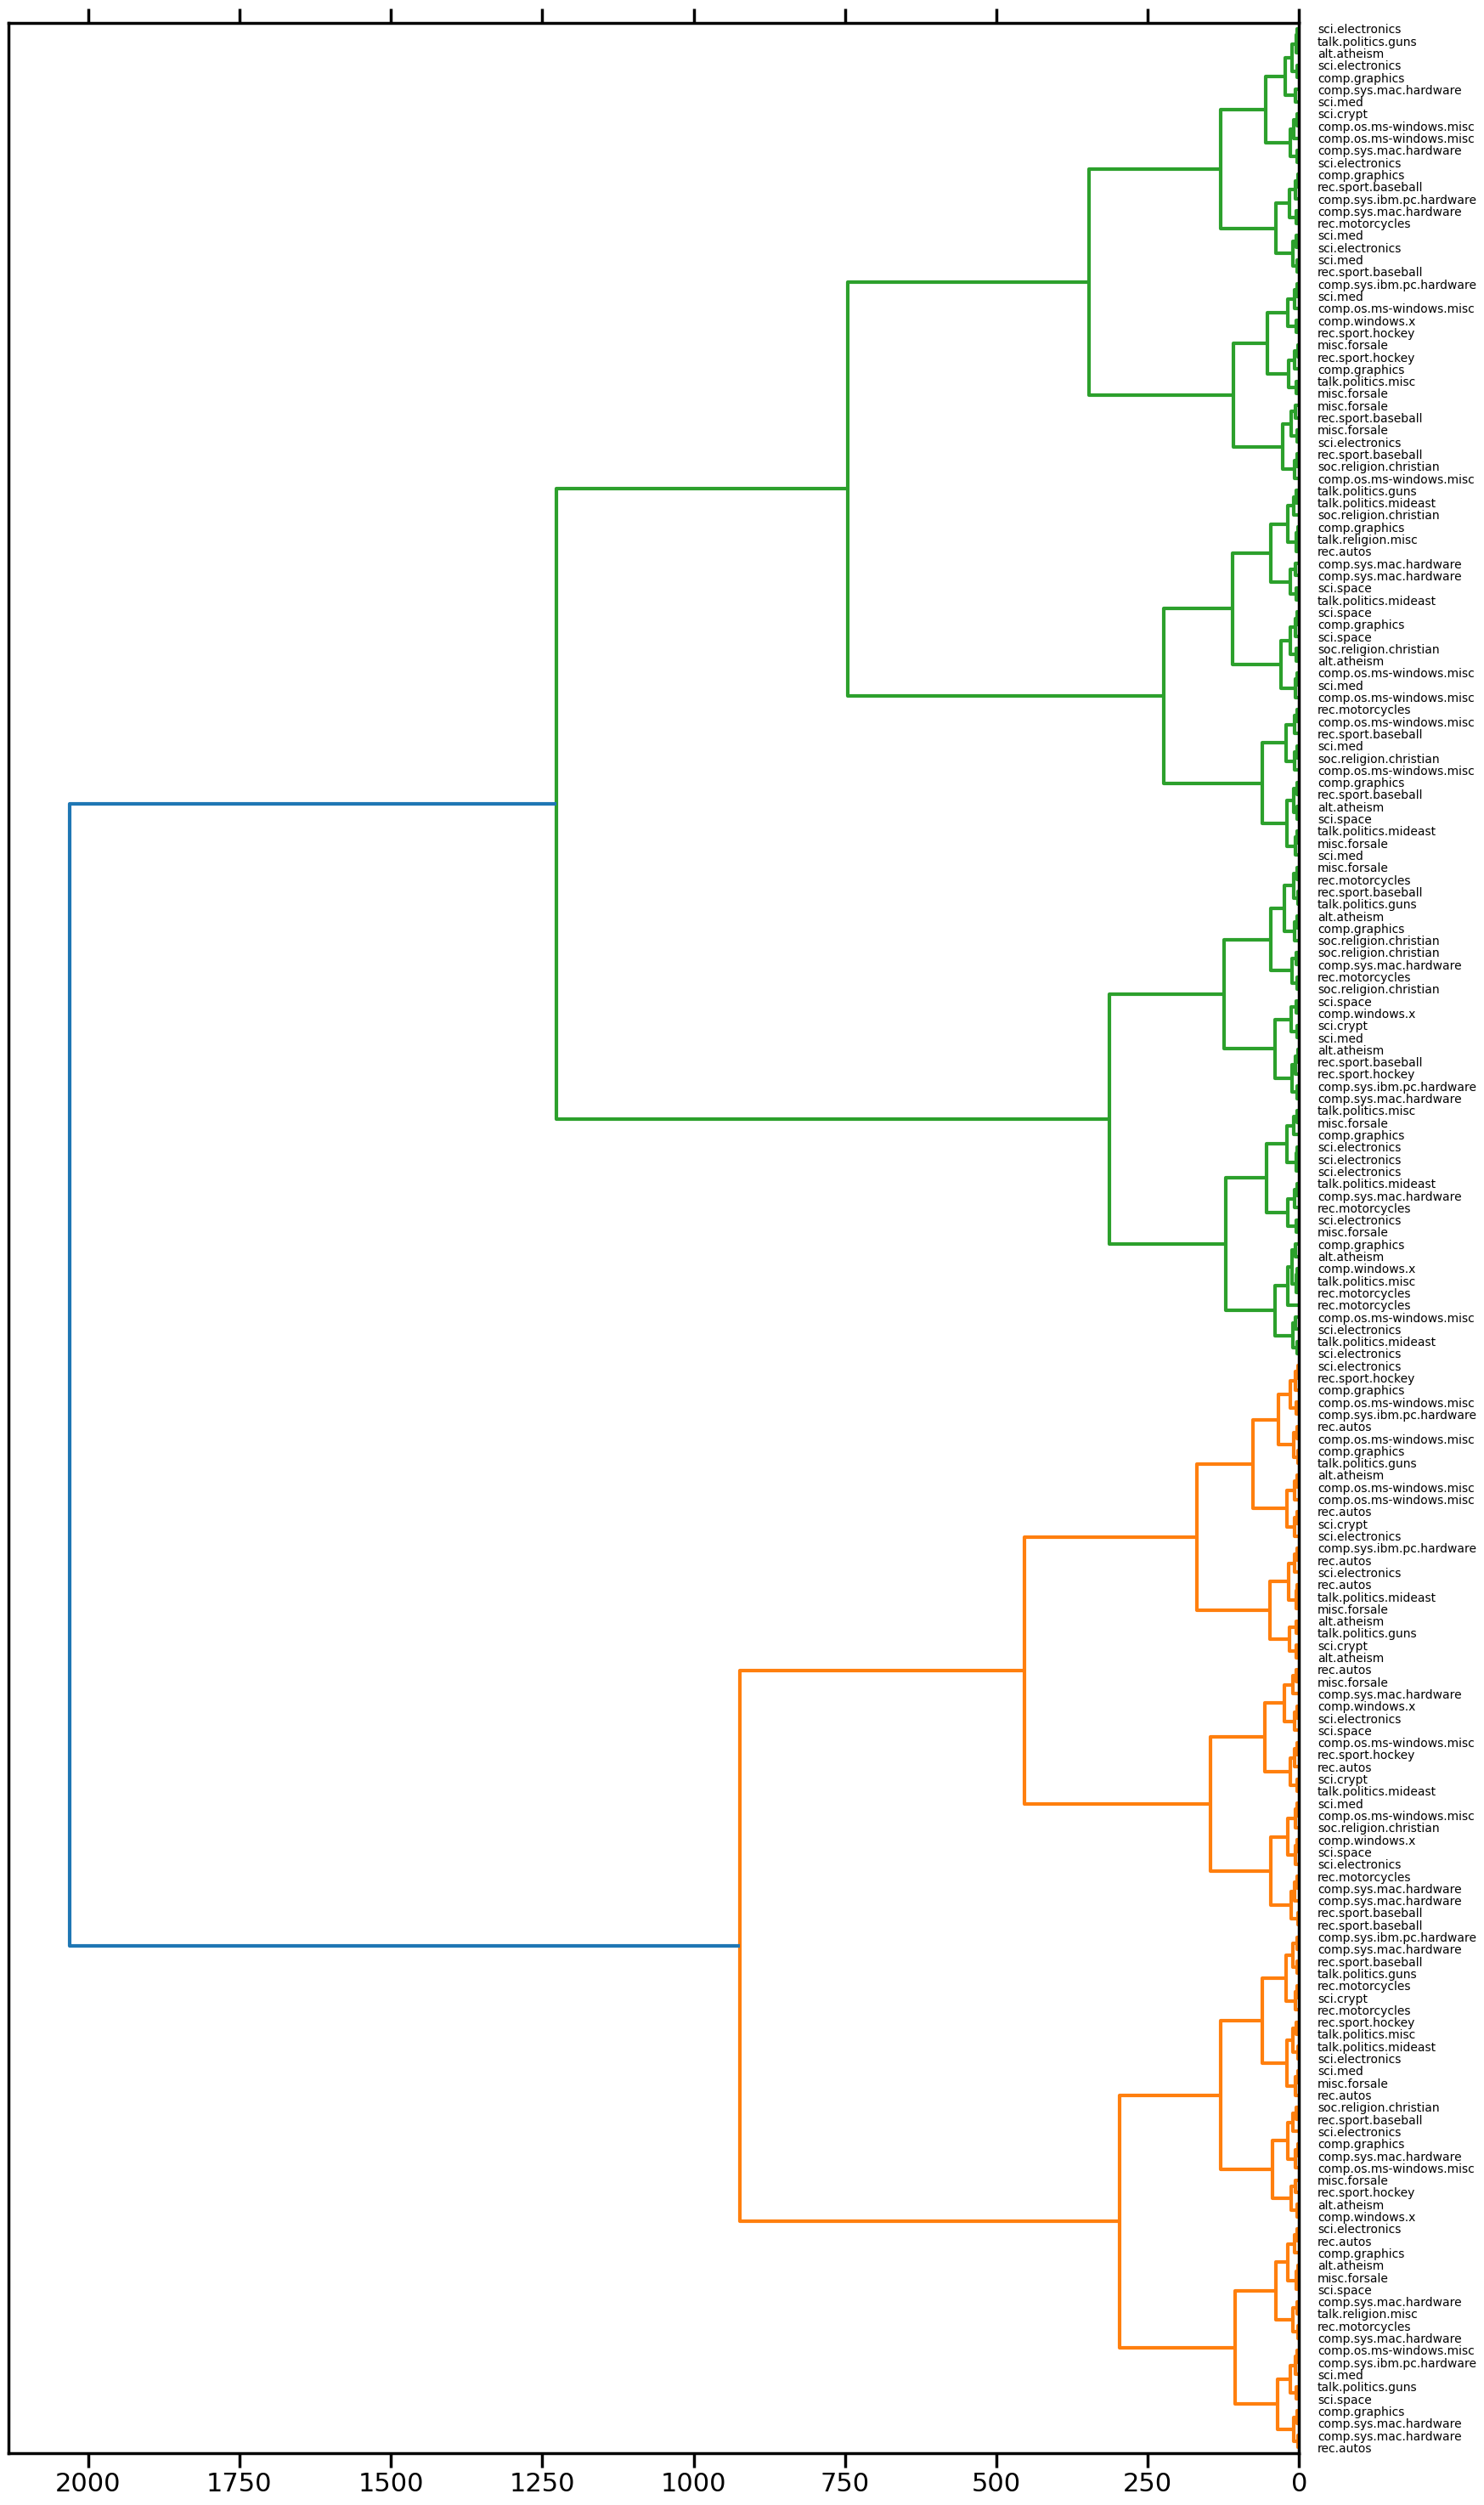

In [53]:
import pandas as pd

# Create a DataFrame for dataframe where titles are the actual category names for each document
document_category_names = [newsgroups_train.target_names[i] for i in newsgroups_train.target]
df = pd.DataFrame({'title': document_category_names})

plot_hierarchical_clusters(linkage_matrix_tfidf,
                           p=200,
                           dataframe=df,
                           figure_size=(18, 30))

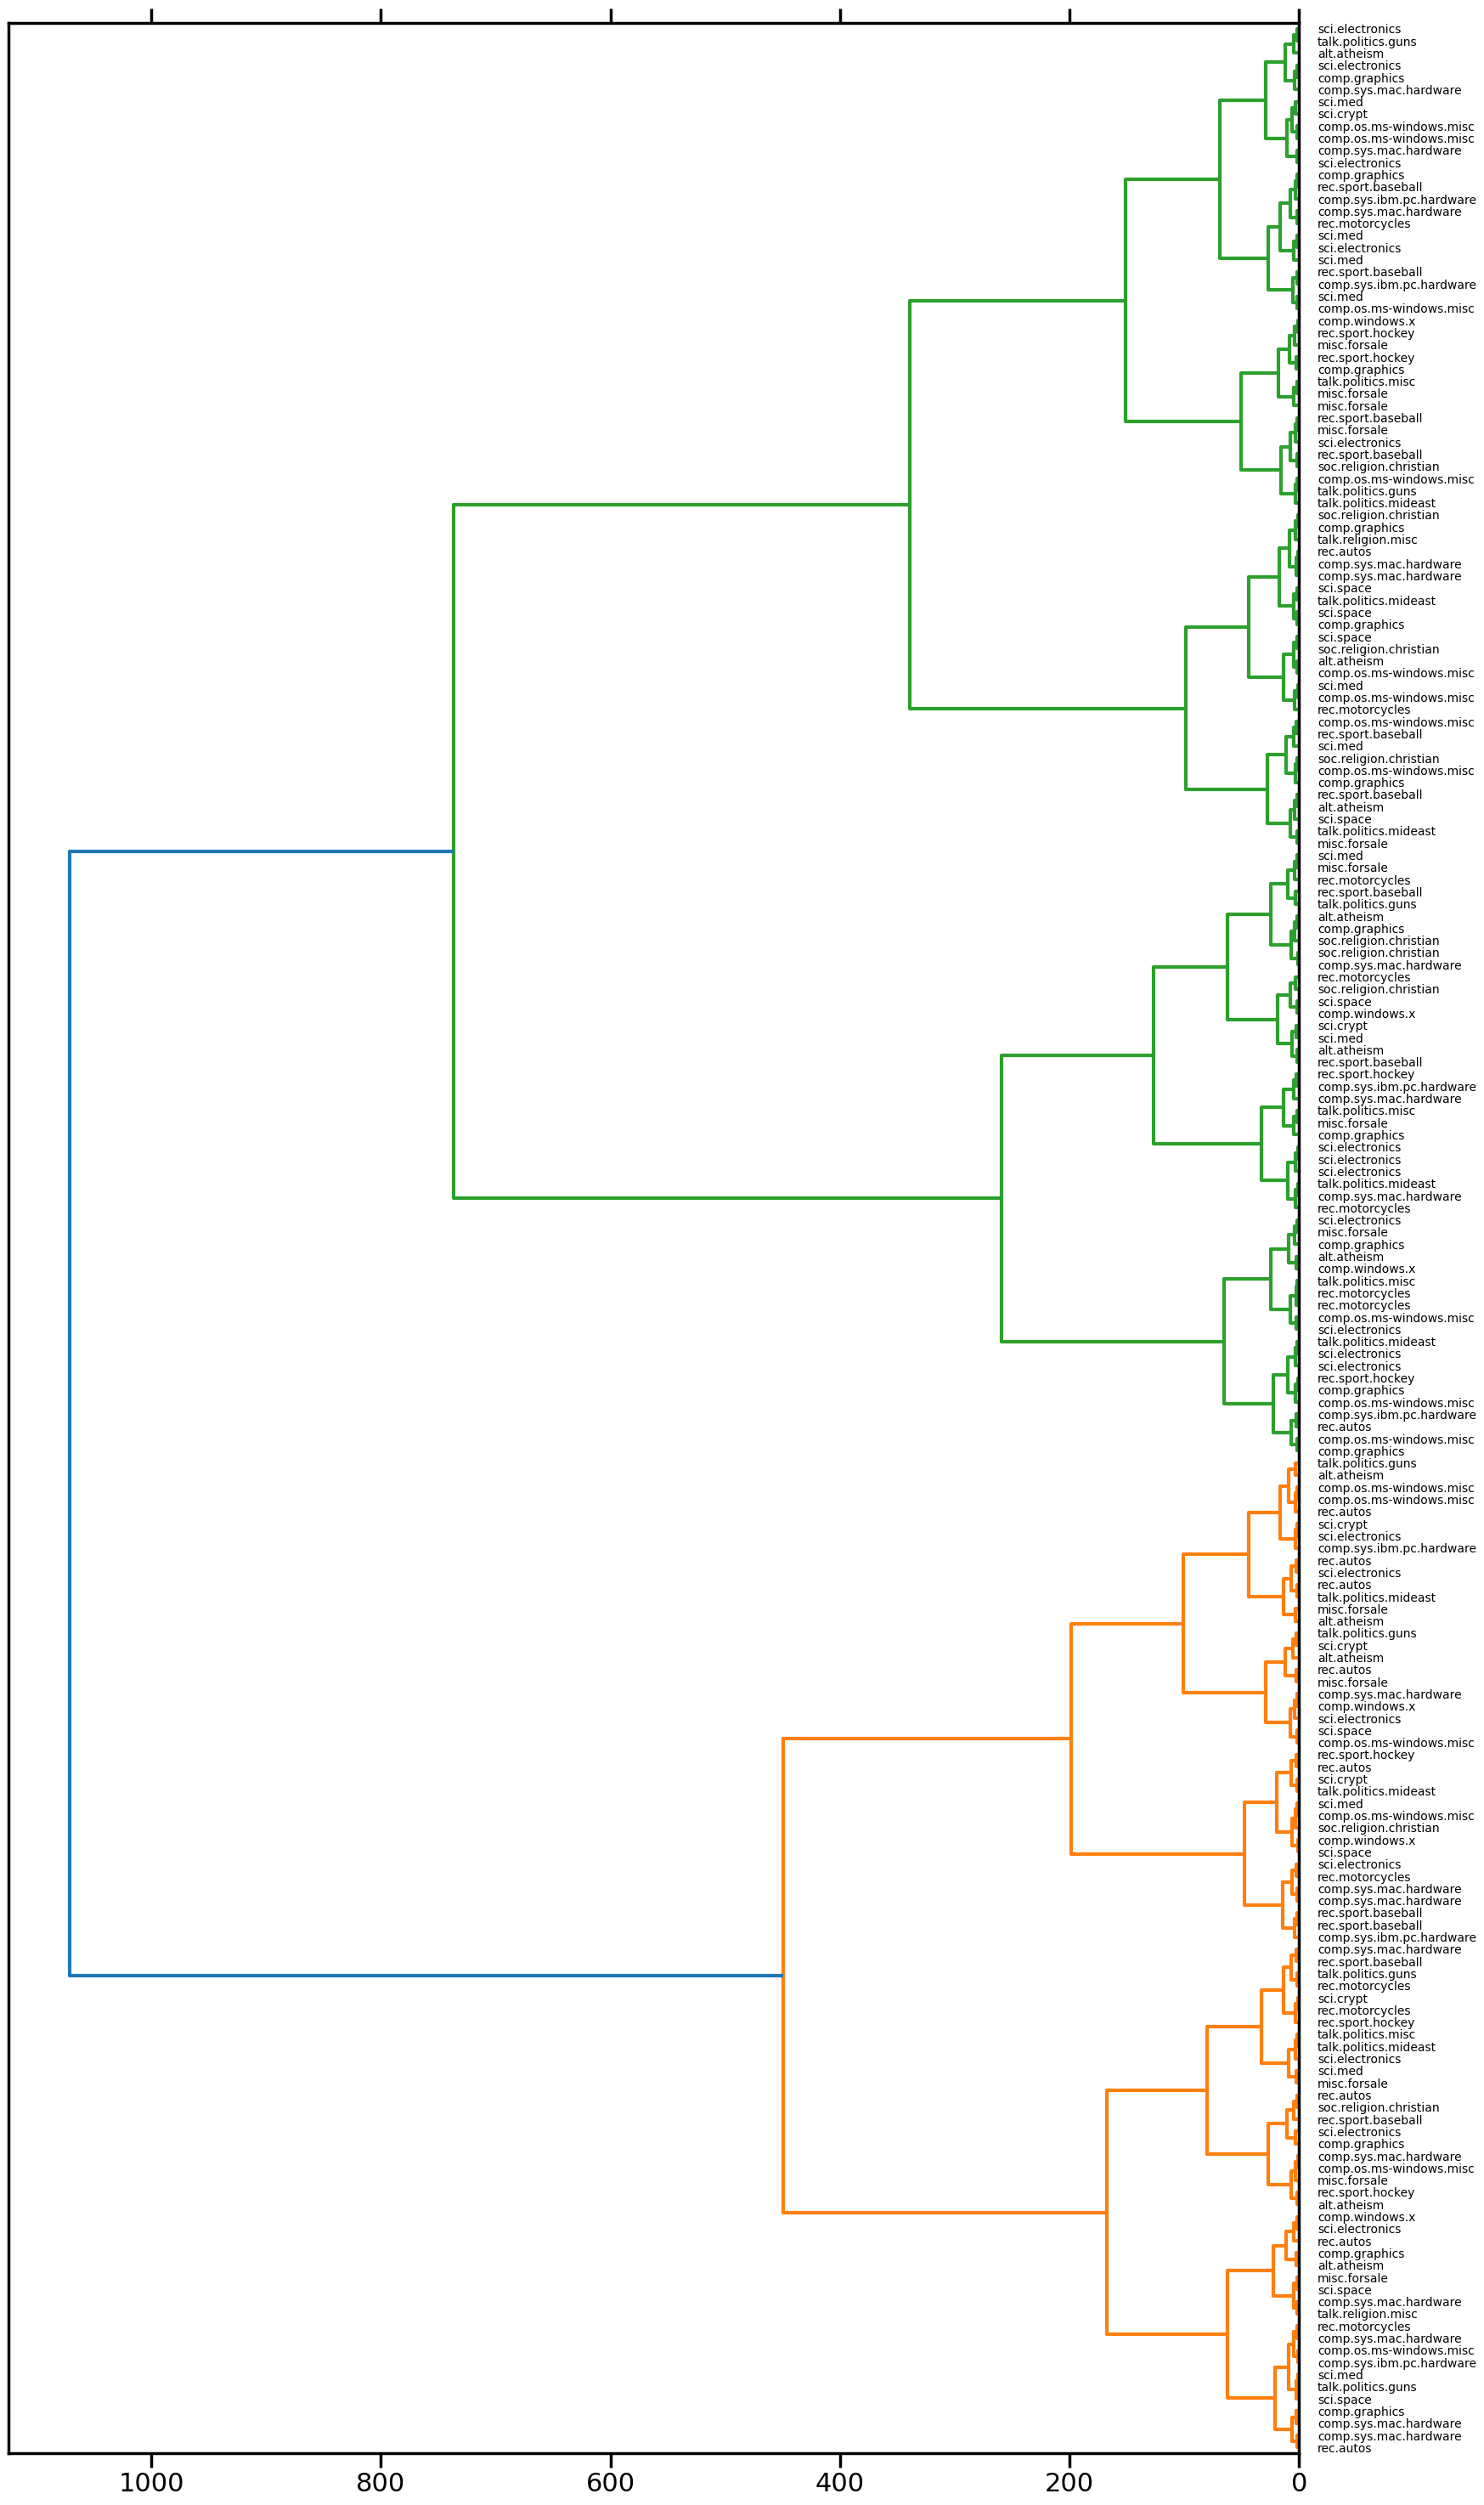

In [54]:
# The 'df' DataFrame created in the previous cell (ByNjlugEPNos) will be reused here.
plot_hierarchical_clusters(linkage_matrix_word2vec,
                           p=200,
                           dataframe=df,
                           figure_size=(18, 30))